# Lab 2 — Baseline com múltiplos datasets

Neste notebook vamos rodar o mesmo pipeline de baseline para 4 datasets diferentes.

A ideia é simples: para cada dataset na lista `keys_to_run`, o código vai:
1. baixar e carregar os dados
2. limpar valores ausentes e aplicar `dropna` antes do split
3. treinar dois modelos baseline (um linear e um de floresta)
4. imprimir as métricas e salvar os resultados

No final, uma tabela compara os melhores modelos de cada dataset.

In [35]:
import os

base = r"C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga"

for root, dirs, files in os.walk(base):
    print(root)
    for d in dirs:
        print("  [DIR]", d)
    for f in files:
        print("  [FILE]", f)

C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga
  [DIR] corruptions
  [DIR] evaluation
  [DIR] tasks
  [DIR] __pycache__
  [FILE] basis.py
  [FILE] utils.py
  [FILE] __init__.py
C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\corruptions
  [DIR] __pycache__
  [FILE] generic.py
  [FILE] image.py
  [FILE] numerical.py
  [FILE] text.py
  [FILE] __init__.py
C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\corruptions\__pycache__
  [FILE] generic.cpython-39.pyc
  [FILE] __init__.cpython-39.pyc
C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\evaluation
  [FILE] basis.py
  [FILE] corruption_impact.py
  [FILE] schema_stresstest.py
  [FILE] schema_validation.py
C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\tasks
  [FILE] income.py
  [FILE] openml.py
  [FILE] reviews.py
  [FILE] shoes.py
C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\__pycache__
  [FILE] basis.cpython-39.pyc
  [FILE] utils.cpython-39.pyc
  [FILE] __init__.cpytho

In [36]:
# 1) Bibliotecas
from __future__ import annotations

import json
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

import sys
from pathlib import Path

import sys
from pathlib import Path

BASE_DIR = Path().resolve()
JENGA_PATH = BASE_DIR / "jenga" / "src"

sys.path.insert(0, str(JENGA_PATH))

import jenga
print("Jenga path:", jenga.__file__)

from jenga.corruptions.generic import MissingValues
print("IMPORT OK")

from jenga.corruptions.generic import MissingValues

import inspect
print(inspect.signature(MissingValues))

from joblib import Parallel, delayed

from lightgbm import LGBMClassifier, LGBMRegressor

import miceforest as mf

# Suprimir warnings verbosos do LightGBM e sklearn em produção

import logging
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('lightgbm').setLevel(logging.ERROR)


Jenga path: C:\Users\kslima\mestrado\cienciaDados\atv2\jenga\src\jenga\__init__.py
IMPORT OK
(column, fraction, na_value=nan, missingness='MCAR')


In [37]:
# 2) Metadados dos datasets e funcoes  que nos ajudam a baixar, extrair e normalizar os dados

DATASETS = {
    "adult": {"task": "classification", "target": "income"},
    "bank_marketing": {"task": "classification", "target": "y"},
    "air_quality_uci": {"task": "regression", "target": "C6H6(GT)"},
    "communities_crime": {"task": "regression", "target": "ViolentCrimesPerPop"},
}

# Tokens que representam valores ausentes
NUMERIC_MISSING_VALUES = [-200, -200.0]

STRING_MISSING_VALUES = [
    "?", " ?", "? ", "NA", "N/A", "na", "n/a", "NaN", "nan", "", " ",
    "unknown", "Unknown", "-200",
]


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if not output_path.exists():
        print(f"[download] {url}")
        urlretrieve(url, output_path)
    else:
        print(f"[cache] {output_path}")
    return output_path


def unzip_file(zip_path: Path, extract_dir: Path) -> Path:
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted"
    if not marker.exists():
        print(f"[extract] {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        marker.write_text("ok\n", encoding="utf-8")
    else:
        print(f"[cache] {extract_dir}")
    return extract_dir


def normalize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace(NUMERIC_MISSING_VALUES, np.nan)
        else:
            df[col] = df[col].astype("string").str.strip()
            df[col] = df[col].replace(STRING_MISSING_VALUES, pd.NA)
    return df
def to_native_dtypes(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    for col in df.columns:
        dtype = df[col].dtype
        if not isinstance(dtype, np.dtype):
            if hasattr(dtype, "numpy_dtype"):
                try:
                    df[col] = df[col].astype(object).where(
                        df[col].notna(), other=np.nan
                    ).astype(float)
                    continue
                except (ValueError, TypeError):
                    pass
            df[col] = df[col].astype(object).where(df[col].notna(), other=None)
    return df

def _to_object_dtype(X):
    if hasattr(X, "astype"):
        return X.astype(object)
    return X

def _to_str_dtype(X):
    return X.astype(str)

In [38]:
# 3) Funcoes. para baixar os datasets automaticamente

# fiz alguns pequenos ajustes caso a caso para facilitar a leitura e evitar erros de parsing

def load_adult(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "adult"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        base / "adult.data",
    )
    test_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
        base / "adult.test",
    )

    columns = [
        "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income",
    ]

    train_df = pd.read_csv(data_file, header=None, names=columns, skipinitialspace=True, na_values=["?", " ?"])
    test_df = pd.read_csv(test_file, header=None, names=columns, skiprows=1, skipinitialspace=True, na_values=["?", " ?"])

    df = pd.concat([train_df, test_df], ignore_index=True)
    df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
    return df, "income", "classification"


def load_bank_marketing(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "bank_marketing"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip",
        base / "bank.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    df = pd.read_csv(extract_dir / "bank-full.csv", sep=";")
    return df, "y", "classification"


def load_air_quality_uci(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "air_quality_uci"
    zip_path = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip",
        base / "AirQualityUCI.zip",
    )
    extract_dir = unzip_file(zip_path, base / "extracted")
    candidates = list(extract_dir.rglob("AirQualityUCI.csv"))
    if not candidates:
        raise FileNotFoundError("Nao encontrei AirQualityUCI.csv dentro do zip.")

    df = pd.read_csv(candidates[0], sep=";", decimal=",")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    for col in ["Date", "Time"]:
        if col in df.columns:
            df = df.drop(columns=[col])
    return df, "C6H6(GT)", "regression"


def load_communities_crime(data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    base = data_dir / "communities_crime"
    data_file = download_file(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data",
        base / "communities.data",
    )
    df = pd.read_csv(data_file, header=None, na_values=["?"])

    cols = [f"col_{i}" for i in range(df.shape[1])]
    cols[-1] = "ViolentCrimesPerPop"
    df.columns = cols
    # colunas  com muito problema
    df = df.drop(columns=[c for c in ["col_0", "col_1", "col_2", "col_3", "col_4"] if c in df.columns])
    return df, "ViolentCrimesPerPop", "regression"


def load_dataset(key: str, data_dir: Path) -> tuple[pd.DataFrame, str, str]:
    if key == "adult":
        return load_adult(data_dir)
    if key == "bank_marketing":
        return load_bank_marketing(data_dir)
    if key == "air_quality_uci":
        return load_air_quality_uci(data_dir)
    if key == "communities_crime":
        return load_communities_crime(data_dir)
    raise ValueError(f"Key desconhecida: {key}")

def inject_mcar(df: pd.DataFrame, missing_rate: float, random_state: int = 42) -> pd.DataFrame:
    corruption = MissingValues(missing_rate=missing_rate, random_state=random_state)
    df_corrupted = corruption.transform(df.copy())
    return df_corrupted


def inject_mar(df: pd.DataFrame, missing_rate: float, random_state: int = 42) -> pd.DataFrame:
    df_corrupted = df.copy()

    np.random.seed(random_state)

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) == 0:
        return inject_mcar(df, missing_rate, random_state)

    ref_col = numeric_cols[0]

    threshold = df[ref_col].median()

    mask = df[ref_col] > threshold

    for col in df.columns:
        prob = np.random.rand(len(df))
        df_corrupted.loc[mask & (prob < missing_rate), col] = np.nan

    return df_corrupted


def inject_mnar(df: pd.DataFrame, missing_rate: float, random_state: int = 42) -> pd.DataFrame:
    df_corrupted = df.copy()

    np.random.seed(random_state)

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) == 0:
        return inject_mcar(df, missing_rate, random_state)

    for col in numeric_cols:
        threshold = df[col].median()
        mask = df[col] > threshold

        prob = np.random.rand(len(df))
        df_corrupted.loc[mask & (prob < missing_rate), col] = np.nan

    return df_corrupted

In [39]:
# 4) Funcoes para separar treino e teste

FAST_MODE            = False
CACHE_DIR            = Path("cache_experimentos")  # OTIMIZADO: pasta dedicada ao cache
MISSING_MECHANISMS   = ["MCAR", "MAR", "MNAR"]
MISSING_RATES        = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
N_ESTIMATORS         = 50   
N_ESTIMATORS_LGBM    = 100 
MAX_ITER_IMPUTER     = 5
SAMPLE_SIZE          = None

def split_X_y(df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.Series]:
    if target not in df.columns:
        raise ValueError(f"Target '{target}' nao esta no dataset.")
    return df.drop(columns=[target]), df[target]


def build_preprocessor(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler() if scale_numeric else "passthrough"),
    ])

    cat_pipeline = Pipeline([
        ("to_object", FunctionTransformer(_to_object_dtype)),  
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("to_str", FunctionTransformer(_to_str_dtype)),       
        ("onehot", make_one_hot_encoder()),
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipeline, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def build_preprocessor_with_imputer(
    X: pd.DataFrame,
    imputer_type: str,
    scale_numeric: bool
) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    # ── imputador numérico 
    if imputer_type in ("dropna", "miceforest"):
        num_imputer = SimpleImputer(strategy="mean")
    elif imputer_type == "simple_mean":
        num_imputer = SimpleImputer(strategy="mean")
    elif imputer_type == "simple_median":
        num_imputer = SimpleImputer(strategy="median")
    elif imputer_type == "simple_freq":
        num_imputer = SimpleImputer(strategy="most_frequent")
    elif imputer_type == "simple_const":
        num_imputer = SimpleImputer(strategy="constant", fill_value=0)
    elif imputer_type.startswith("knn_"):
        k = int(imputer_type.split("_")[1])
        num_imputer = KNNImputer(n_neighbors=k)  # n_jobs removido: nao suportado nesta versao do sklearn
    elif imputer_type == "iterative":
        num_imputer = IterativeImputer(
            max_iter=MAX_ITER_IMPUTER,
            tol=1e-2,            # OTIMIZADO: tolerância maior → converge mais rápido
            initial_strategy="mean",
            random_state=0,
            skip_complete=True,  # OTIMIZADO: pula colunas sem nulos
        )
    else:
        raise ValueError(f"Imputer desconhecido: {imputer_type}")

    num_pipeline = Pipeline([
        ("imputer", num_imputer),
        ("scaler", StandardScaler() if scale_numeric else "passthrough"),
    ])

    cat_pipeline = Pipeline([
        ("to_object", FunctionTransformer(_to_object_dtype)),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("to_str", FunctionTransformer(_to_str_dtype)),
        ("onehot", make_one_hot_encoder()),
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipeline, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def inject_missing_values(df, target, mechanism, missing_rate, random_state):
    df_corrupted = df.copy()

    for col in df_corrupted.columns:
        try:
            df_corrupted[col] = df_corrupted[col].astype(float)
        except (ValueError, TypeError):
            pass

    y = df_corrupted[target]
    X = df_corrupted.drop(columns=[target]).copy()

    X_original = X.copy()

    for col in X.columns:
        corruption = MissingValues(
            column=col,
            fraction=missing_rate,
            missingness=mechanism
        )
        X = corruption.transform(X)

    null_mask = X.isnull() & X_original.notna()

    df_final = X.copy()
    df_final[target] = y

    return df_final, X_original, null_mask 


def compute_imputation_quality(
    X_original: pd.DataFrame,
    X_imputed: pd.DataFrame,
    null_mask: pd.DataFrame,
) -> dict:
    """
    Compara valores imputados com os valores originais apenas
    nas posições onde nulos foram injetados artificialmente.

    """
    numeric_cols     = X_original.select_dtypes(include=[np.number]).columns
    categorical_cols = [c for c in X_original.columns if c not in numeric_cols]

    mae_list, rmse_list, acc_list = [], [], []
    n_num, n_cat = 0, 0

    for col in numeric_cols:
        mask = null_mask[col] if col in null_mask.columns else pd.Series(False, index=X_original.index)
        idx  = mask[mask].index
        if len(idx) == 0:
            continue
        orig = pd.to_numeric(X_original.loc[idx, col], errors="coerce").dropna()
        imp  = pd.to_numeric(X_imputed.loc[orig.index, col],  errors="coerce").dropna()
        common = orig.index.intersection(imp.index)
        if len(common) == 0:
            continue
        o, i = orig[common].values, imp[common].values
        mae_list.append(mean_absolute_error(o, i))
        rmse_list.append(np.sqrt(mean_squared_error(o, i)))
        n_num += len(common)

    for col in categorical_cols:
        mask = null_mask[col] if col in null_mask.columns else pd.Series(False, index=X_original.index)
        idx  = mask[mask].index
        if len(idx) == 0:
            continue
        orig = X_original.loc[idx, col].dropna().astype(str)
        imp  = X_imputed.loc[orig.index, col].fillna("__missing__").astype(str)
        common = orig.index.intersection(imp.index)
        if len(common) == 0:
            continue
        acc_list.append(accuracy_score(orig[common], imp[common]))
        n_cat += len(common)

    return {
        "imp_mae_num":  float(np.mean(mae_list))  if mae_list  else None,
        "imp_rmse_num": float(np.mean(rmse_list)) if rmse_list else None,
        "imp_acc_cat":  float(np.mean(acc_list))  if acc_list  else None,
        "imp_n_num":    n_num,
        "imp_n_cat":    n_cat,
    }

def impute_with_miceforest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    random_state: int = 42,
    iterations: int = 1,   # OTIMIZADO: reduzido de 2 → 1
    max_cols: int = 30,    # OTIMIZADO: reduzido de 50 → 30
) -> tuple[pd.DataFrame, pd.DataFrame]:

    X_train_n = to_native_dtypes(X_train.copy())
    X_test_n  = to_native_dtypes(X_test.copy())

    X_train_n = X_train_n.reset_index(drop=True)
    X_test_n  = X_test_n.reset_index(drop=True)

    cat_cols = X_train_n.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in cat_cols:
        combined = pd.concat([X_train_n[col], X_test_n[col]], axis=0)
        cats = combined.dropna().unique()
        cat_map = {v: i for i, v in enumerate(cats)}
        X_train_n[col] = X_train_n[col].map(cat_map).astype(float)
        X_test_n[col]  = X_test_n[col].map(cat_map).astype(float)

    all_cols = X_train_n.columns.tolist()
    if len(all_cols) > max_cols:
        variances = X_train_n.var(numeric_only=True).nlargest(max_cols)
        selected_cols = variances.index.tolist()
        remaining_cols = [c for c in all_cols if c not in selected_cols]
        print(f"[miceforest] {len(all_cols)} colunas → usando top-{max_cols} por variância")
    else:
        selected_cols  = all_cols
        remaining_cols = []

    X_tr_sel = X_train_n[selected_cols].copy()
    X_te_sel = X_test_n[selected_cols].copy()

    try:
        kernel = mf.ImputationKernel(
            X_tr_sel,
            random_state=random_state,
        )
        kernel.mice(iterations, verbose=False)

        X_train_imp_sel = kernel.complete_data(dataset=0)
        new_data_kernel = kernel.impute_new_data(
            new_data=X_te_sel,
            random_state=random_state,
        )
        X_test_imp_sel = new_data_kernel.complete_data(dataset=0)

    except Exception as e:
        import traceback
        traceback.print_exc()
        err_msg = str(e) if str(e).strip() else type(e).__name__
        print(f"  [miceforest] fallback SimpleImputer ({err_msg})")
        from sklearn.impute import SimpleImputer
        imp = SimpleImputer(strategy="mean")
        X_train_imp_sel = pd.DataFrame(
            imp.fit_transform(X_tr_sel),
            columns=X_tr_sel.columns, index=X_tr_sel.index
        )
        X_test_imp_sel = pd.DataFrame(
            imp.transform(X_te_sel),
            columns=X_te_sel.columns, index=X_te_sel.index
        )

    if remaining_cols:
        from sklearn.impute import SimpleImputer
        imp_rem = SimpleImputer(strategy="mean")
        X_tr_rem = pd.DataFrame(
            imp_rem.fit_transform(X_train_n[remaining_cols]),
            columns=remaining_cols, index=X_train_n.index
        )
        X_te_rem = pd.DataFrame(
            imp_rem.transform(X_test_n[remaining_cols]),
            columns=remaining_cols, index=X_test_n.index
        )
        X_train_imp = pd.concat([X_train_imp_sel, X_tr_rem], axis=1)[all_cols]
        X_test_imp  = pd.concat([X_test_imp_sel,  X_te_rem],  axis=1)[all_cols]
    else:
        X_train_imp = X_train_imp_sel
        X_test_imp  = X_test_imp_sel

    return X_train_imp, X_test_imp


def _print_metrics(name: str, metrics: dict, task: str) -> None:
    if task == "classification":
        acc = metrics.get("accuracy")
        mf1 = metrics.get("macro_f1")
        wf1 = metrics.get("weighted_f1")
        if acc is None:
            print(f"     x  {name:<26} ERRO")
        else:
            bar = "#" * int(wf1 * 20) + "-" * (20 - int(wf1 * 20))
            print(f"     ok {name:<26} acc={acc:.3f}  mf1={mf1:.3f}  wf1={wf1:.3f}  [{bar}]")
    else:
        mae  = metrics.get("mae")
        rmse = metrics.get("rmse")
        r2   = metrics.get("r2")
        if r2 is None:
            print(f"     x  {name:<26} ERRO")
        else:
            bar = "#" * max(0, int(r2 * 20)) + "-" * (20 - max(0, int(r2 * 20)))
            print(f"     ok {name:<26} mae={mae:.4f}  rmse={rmse:.4f}  r2={r2:.4f}  [{bar}]")


def run_classification(X: pd.DataFrame, y: pd.Series, test_size: float, random_state: int) -> dict:

    y = pd.Series(y.to_numpy(dtype=object, na_value=np.nan), index=y.index)
    y = y.dropna()
    y = y.astype(str)
    X = X.loc[y.index]
    X = to_native_dtypes(X)  

    class_counts = y.value_counts()
    stratify = y if int(class_counts.min()) >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify
    )

    models = {
        "logistic_regression": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=True)),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "random_forest": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                random_state=random_state,
                n_jobs=-1,  # OTIMIZADO: era n_jobs=1
                class_weight="balanced_subsample",
            )),
        ]),
        "lightgbm": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", LGBMClassifier(
                n_estimators=N_ESTIMATORS_LGBM,
                random_state=random_state,
                n_jobs=-1,  # OTIMIZADO: era n_jobs=1
                class_weight="balanced",
                verbosity=-1,
            )),
        ]),
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        metrics = {
            "accuracy": float(accuracy_score(y_test, pred)),
            "macro_f1": float(f1_score(y_test, pred, average="macro")),
            "weighted_f1": float(f1_score(y_test, pred, average="weighted")),
        }

        results[name] = metrics
        _print_metrics(name, metrics, task="classification")

    return results

def run_classification_with_imputation(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float,
    random_state: int,
    X_original: pd.DataFrame = None,
    null_mask: pd.DataFrame = None,
) -> dict:

    IMPUTERS_LIST = [
        "dropna", "simple_mean", "simple_median", "simple_freq",
        "simple_const", "knn_3", "knn_5", "knn_7", "iterative", "miceforest",
    ]

    y = pd.Series(y.to_numpy(dtype=object, na_value=np.nan), index=y.index)
    y = y.dropna()
    y = y.astype(str)
    X = X.loc[y.index].copy()
    X = to_native_dtypes(X)

    if len(y) == 0:
        raise RuntimeError("Target vazia após limpeza.")

    class_counts = y.value_counts(dropna=False)
    stratify = y if int(class_counts.min()) >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )

    results = {}

    for imp in IMPUTERS_LIST:
        print(f"  > imputador: {imp}")

        if imp == "dropna":
            mask_train = ~X_train.isnull().any(axis=1)
            mask_test  = ~X_test.isnull().any(axis=1)
            X_tr = X_train[mask_train]
            y_tr = y_train[mask_train]
            X_te = X_test[mask_test]
            y_te = y_test[mask_test]
            if len(y_tr) == 0 or len(y_te) == 0:
                results[imp] = {}
                continue

        elif imp == "miceforest":
            X_tr_imp, X_te_imp = impute_with_miceforest(
                X_train, X_test, random_state=random_state
            )
            X_tr, y_tr = X_tr_imp, y_train
            X_te, y_te = X_te_imp, y_test

        else:
            X_tr, y_tr, X_te, y_te = X_train, y_train, X_test, y_test

        # ── qualidade da imputação ────────────────────────────────────────────
        imp_quality = {}
        if X_original is not None and null_mask is not None and imp != "dropna":
            try:
                train_idx = X_train.index
                num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
                cat_cols = [c for c in X_train.columns if c not in num_cols]

                if imp == "miceforest":
                    X_tr_for_quality = pd.DataFrame(
                        X_tr.values, index=train_idx, columns=X_train.columns
                    )
                else:
                    if imp == "simple_mean":
                        num_imp = SimpleImputer(strategy="mean")
                    elif imp == "simple_median":
                        num_imp = SimpleImputer(strategy="median")
                    elif imp == "simple_freq":
                        num_imp = SimpleImputer(strategy="most_frequent")
                    elif imp == "simple_const":
                        num_imp = SimpleImputer(strategy="constant", fill_value=0)
                    elif imp.startswith("knn_"):
                        num_imp = KNNImputer(n_neighbors=int(imp.split("_")[1]))
                    elif imp == "iterative":
                        num_imp = IterativeImputer(
                            max_iter=MAX_ITER_IMPUTER, initial_strategy="mean", random_state=0
                        )
                    else:
                        num_imp = SimpleImputer(strategy="mean")

                    if num_cols:
                        arr_num = num_imp.fit_transform(X_tr[num_cols])
                        X_num_imp = pd.DataFrame(arr_num, index=train_idx, columns=num_cols)
                    else:
                        X_num_imp = pd.DataFrame(index=train_idx)

                    if cat_cols:
                        cat_imp = SimpleImputer(strategy="most_frequent")
                        arr_cat = cat_imp.fit_transform(X_tr[cat_cols].astype(object))
                        X_cat_imp = pd.DataFrame(arr_cat, index=train_idx, columns=cat_cols)
                        X_tr_for_quality = pd.concat([X_num_imp, X_cat_imp], axis=1)[X_train.columns]
                    else:
                        X_tr_for_quality = X_num_imp[X_train.columns] if num_cols else X_tr.copy()

                imp_quality = compute_imputation_quality(
                    X_original.loc[train_idx],
                    X_tr_for_quality,
                    null_mask.loc[train_idx],
                )
            except Exception as e:
                print(f"     [imp_quality erro] {imp}: {e}")
                imp_quality = {}
        # ─────────────────────────────────────────────────────────────────────

        models = {
            "logistic_regression": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, True)),
                ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
            ]),
            "random_forest": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, False)),
                ("model", RandomForestClassifier(
                    n_estimators=N_ESTIMATORS, max_depth=10,
                    random_state=random_state, n_jobs=-1, 
                    class_weight="balanced_subsample",
                )),
            ]),
            "lightgbm": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, False)),
                ("model", LGBMClassifier(
                    n_estimators=N_ESTIMATORS_LGBM, max_depth=10,
                    random_state=random_state, n_jobs=-1, 
                    class_weight="balanced", verbosity=-1,
                )),
            ]),
        }

        results[imp] = {}

        for name, model in models.items():
            try:
                model.fit(X_tr, y_tr)
                pred = model.predict(X_te)
                metrics = {
                    "accuracy":    float(accuracy_score(y_te, pred)),
                    "macro_f1":    float(f1_score(y_te, pred, average="macro")),
                    "weighted_f1": float(f1_score(y_te, pred, average="weighted")),
                }
            except Exception as e:
                print(f"     x  {name}: {e}")
                metrics = {"accuracy": None, "macro_f1": None, "weighted_f1": None}

            metrics.update(imp_quality)
            results[imp][name] = metrics
            _print_metrics(name, metrics, task="classification")

    return results


def run_regression_with_imputation(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float,
    random_state: int,
    X_original: pd.DataFrame = None,
    null_mask: pd.DataFrame = None,
) -> dict:

    IMPUTERS_LIST = [
        "dropna", "simple_mean", "simple_median", "simple_freq",
        "simple_const", "knn_3", "knn_5", "knn_7", "iterative", "miceforest",
    ]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    results = {}

    for imp in IMPUTERS_LIST:
        print(f"  > imputador: {imp}")

        if imp == "dropna":
            mask_train = ~X_train.isnull().any(axis=1)
            mask_test  = ~X_test.isnull().any(axis=1)
            X_tr = X_train[mask_train]
            y_tr = y_train[mask_train]
            X_te = X_test[mask_test]
            y_te = y_test[mask_test]
            if len(y_tr) == 0 or len(y_te) == 0:
                results[imp] = {}
                continue

        elif imp == "miceforest":
            X_tr_imp, X_te_imp = impute_with_miceforest(
                X_train, X_test, random_state=random_state
            )
            X_tr, y_tr = X_tr_imp, y_train
            X_te, y_te = X_te_imp, y_test

        else:
            X_tr, y_tr, X_te, y_te = X_train, y_train, X_test, y_test

        # ── qualidade da imputação ────────────────────────────────────────────
        imp_quality = {}
        if X_original is not None and null_mask is not None and imp != "dropna":
            try:
                train_idx = X_train.index
                num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
                cat_cols = [c for c in X_train.columns if c not in num_cols]

                if imp == "miceforest":
                    X_tr_for_quality = pd.DataFrame(
                        X_tr.values, index=train_idx, columns=X_train.columns
                    )
                else:
                    if imp == "simple_mean":
                        num_imp = SimpleImputer(strategy="mean")
                    elif imp == "simple_median":
                        num_imp = SimpleImputer(strategy="median")
                    elif imp == "simple_freq":
                        num_imp = SimpleImputer(strategy="most_frequent")
                    elif imp == "simple_const":
                        num_imp = SimpleImputer(strategy="constant", fill_value=0)
                    elif imp.startswith("knn_"):
                        num_imp = KNNImputer(n_neighbors=int(imp.split("_")[1]))
                    elif imp == "iterative":
                        num_imp = IterativeImputer(
                            max_iter=MAX_ITER_IMPUTER, initial_strategy="mean", random_state=0
                        )
                    else:
                        num_imp = SimpleImputer(strategy="mean")

                    if num_cols:
                        arr_num = num_imp.fit_transform(X_tr[num_cols])
                        X_num_imp = pd.DataFrame(arr_num, index=train_idx, columns=num_cols)
                    else:
                        X_num_imp = pd.DataFrame(index=train_idx)

                    if cat_cols:
                        cat_imp = SimpleImputer(strategy="most_frequent")
                        arr_cat = cat_imp.fit_transform(X_tr[cat_cols].astype(object))
                        X_cat_imp = pd.DataFrame(arr_cat, index=train_idx, columns=cat_cols)
                        X_tr_for_quality = pd.concat([X_num_imp, X_cat_imp], axis=1)[X_train.columns]
                    else:
                        X_tr_for_quality = X_num_imp[X_train.columns] if num_cols else X_tr.copy()

                imp_quality = compute_imputation_quality(
                    X_original.loc[train_idx],
                    X_tr_for_quality,
                    null_mask.loc[train_idx],
                )
            except Exception as e:
                print(f"     [imp_quality erro] {imp}: {e}")
                imp_quality = {}

        models = {
            "ridge_regression": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, True)),
                ("model", Ridge(alpha=1.0)),
            ]),
            "random_forest": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, False)),
                ("model", RandomForestRegressor(
                    n_estimators=N_ESTIMATORS, max_depth=10,
                    random_state=random_state, n_jobs=-1,  
                )),
            ]),
            "lightgbm": Pipeline([
                ("preprocess", build_preprocessor_with_imputer(X_tr, imp, False)),
                ("model", LGBMRegressor(
                    n_estimators=N_ESTIMATORS_LGBM, max_depth=10,
                    random_state=random_state, n_jobs=-1,  
                    verbosity=-1,
                )),
            ]),
        }

        results[imp] = {}

        for name, model in models.items():
            try:
                model.fit(X_tr, y_tr)
                pred = model.predict(X_te)
                mse = mean_squared_error(y_te, pred)
                metrics = {
                    "mae":  float(mean_absolute_error(y_te, pred)),
                    "rmse": float(np.sqrt(mse)),
                    "r2":   float(r2_score(y_te, pred)),
                }
            except Exception as e:
                print(f"     x  {name}: {e}")
                metrics = {"mae": None, "rmse": None, "r2": None}

            metrics.update(imp_quality)
            results[imp][name] = metrics
            _print_metrics(name, metrics, task="regression")

    return results

def run_regression(X: pd.DataFrame, y: pd.Series, test_size: float, random_state: int) -> dict:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    models = {
        "ridge_regression": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=True)),
            ("model", Ridge(alpha=1.0)),
        ]),
        "random_forest": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", RandomForestRegressor(
                n_estimators=N_ESTIMATORS, 
                max_depth=10,
                random_state=random_state,
                n_jobs=1
            )),
        ]),
        "lightgbm": Pipeline([
            ("preprocess", build_preprocessor(X_train, scale_numeric=False)),
            ("model", LGBMRegressor(
                n_estimators=N_ESTIMATORS_LGBM,
                max_depth=10,
                random_state=random_state,
                n_jobs=1,
                verbosity=-1,
            )),
        ]),
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mse = mean_squared_error(y_test, pred)
        metrics = {
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": float(np.sqrt(mse)),
            "r2": float(r2_score(y_test, pred)),
        }

        results[name] = metrics
        _print_metrics(name, metrics, task="regression")

    return results

# FUNÇÃO PRINCIPAL
import time
import sys
import json

def run_one_dataset(
    key: str,
    out_dir: str = "data",
    test_size: float = 0.2,
    random_state: int = 42,
    exp_cache: dict | None = None,    # OTIMIZADO: cache de experimentos ja feitos
    prog_cache_path=None,             # CORRIGIDO: caminho para salvar progresso em disco
    seed_ref: int = 0,                # CORRIGIDO: seed usada para identificar o progress file
) -> dict:
    """
    exp_cache: dict com chaves "MECH_RATE" -> resultado ja calculado.
    Permite retomar de onde parou sem refazer experimentos concluidos.
    """

    data_dir = Path(out_dir)
    df, target, task = load_dataset(key, data_dir=data_dir)
    
    if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=random_state).reset_index(drop=True)
        print(f"  [FAST] amostra de {SAMPLE_SIZE} linhas")

    SEP = "=" * 72
    task_icon = "CLASSIFICACAO" if task == "classification" else "REGRESSAO"
    print(f"\n{SEP}")
    print(f"  {task_icon}  |  {key.upper()}  |  target: {target}")
    print(SEP)

    df = normalize_missing_values(df)
    df = to_native_dtypes(df) 

    df[target] = df[target].astype(object)
    df = df[df[target].notna()].copy()

    if df.empty:
        raise RuntimeError("Dataset vazio apos limpeza.")

    X, y = split_X_y(df, target)

    y = pd.Series([np.nan if v is pd.NA else v for v in y.astype(object)], index=y.index, dtype=object)

    if task == "classification":
        y = y.dropna()
        X = X.loc[y.index]

        X = to_native_dtypes(X)

        y = y.astype(object).astype(str)

        vc = y.value_counts()
        total = vc.sum()
        dist_str = "  |  ".join(f"{cls}: {cnt} ({cnt/total:.0%})" for cls, cnt in vc.items())
        print(f"  classes: {dist_str}")

        baseline_results = run_classification(X, y, test_size, random_state)

    else:
        y = pd.to_numeric(y, errors="coerce")
        valid = y.notna()

        X = X.loc[valid]
        X = to_native_dtypes(X)
        y = y.loc[valid]

        baseline_results = run_regression(X, y, test_size, random_state)

    # EXPERIMENTOS
    missing_mechanisms = MISSING_MECHANISMS
    missing_rates      = MISSING_RATES

    if exp_cache is None:
        exp_cache = {}

    import json  # garante disponibilidade dentro do processo loky

    all_results = []

    all_results.append({
        "dataset": key,
        "mechanism": "NONE",
        "rate": 0,
        "results": baseline_results
    })

    total_exps = len(missing_mechanisms) * len(missing_rates)
    done_exps  = len(exp_cache)

    for mech in missing_mechanisms:
        for rate in missing_rates:
            pct     = int(rate * 100)
            exp_key = f"{mech}_{pct}"

            # OTIMIZADO: pula experimento ja concluido
            if exp_key in exp_cache:
                print(f"  [cache] {mech} {pct:2d}%  [{key}]")
                all_results.append(exp_cache[exp_key])
                continue

            print(f"\n  EXPERIMENTO  {mech}  {pct:2d}%  [{key}]  ({done_exps+1}/{total_exps})")
            print(f"  {chr(45)*50}")

            df_missing, X_original_exp, null_mask_exp = inject_missing_values(
                df,
                target=target,
                mechanism=mech,
                missing_rate=rate,
                random_state=random_state
            )

            X, y = split_X_y(df_missing, target)

            X = to_native_dtypes(X)
            y = pd.Series(
                [np.nan if (v is pd.NA or (isinstance(v, float) and np.isnan(v))) else v
                for v in y],
                index=y.index,
                dtype=object
            )

            if task == "classification":
                valid = y.notna()
                X = X.loc[valid]
                y = y.loc[valid].astype(str)
                res = run_classification_with_imputation(X, y, test_size, random_state,
                                         X_original_exp, null_mask_exp)
            else:
                y = pd.to_numeric(y, errors="coerce")
                valid = y.notna()
                X = X.loc[valid]
                y = y.loc[valid]
                res = run_regression_with_imputation(X, y, test_size, random_state,
                                     X_original_exp, null_mask_exp)

            exp_result = {
                "dataset":   key,
                "mechanism": mech,
                "rate":      rate,
                "results":   res
            }
            all_results.append(exp_result)

            # OTIMIZADO: salva checkpoint por experimento imediatamente
            exp_cache[exp_key] = exp_result
            done_exps += 1

            # CORRIGIDO: persiste progress em disco a cada experimento concluido
            if prog_cache_path is not None:
                partial = {"key": key, "seed": seed_ref, "exp_cache": exp_cache}
                with open(prog_cache_path, "w", encoding="utf-8") as _f:
                    json.dump(partial, _f, ensure_ascii=False)

    return {
        "key":         key,
        "task":        task,
        "results":     baseline_results,
        "experiments": all_results,
        "exp_cache":   exp_cache,   # retorna cache atualizado para persistencia
    }

In [40]:
# 5) Configuracao da execucao

# ============================================================
#    FAST_MODE: True = rápido para testes
#               False = completo para resultados finais
# ============================================================
FAST_MODE = False

# Parametros globais
out_dir = "data"
test_size = 0.2
random_state = 42

datasets_experiment = [
    "adult",
    "bank_marketing",
    "air_quality_uci",
    "communities_crime",
]

if FAST_MODE:
    MISSING_MECHANISMS = ["MCAR"]
    MISSING_RATES      = [0.05, 0.10]
    N_ESTIMATORS       = 10
    N_ESTIMATORS_LGBM  = 50
    MAX_ITER_IMPUTER   = 2
    SAMPLE_SIZE        = 5000
    print("⚡ FAST MODE — resultados aproximados para testes")
else:
    MISSING_MECHANISMS = ["MCAR", "MAR", "MNAR"]
    MISSING_RATES      = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
    N_ESTIMATORS       = 50
    N_ESTIMATORS_LGBM  = 100
    MAX_ITER_IMPUTER   = 5
    SAMPLE_SIZE        = None
    print("🔬 FULL MODE — execução completa")

datasets_experiment

🔬 FULL MODE — execução completa


['adult', 'bank_marketing', 'air_quality_uci', 'communities_crime']

In [41]:
#barra de progresso
from tqdm import tqdm
from joblib import Parallel, delayed

class ParallelTqdm(Parallel):
    def __init__(self, total=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.total = total

    def __call__(self, *args, **kwargs):
        with tqdm(total=self.total) as self._pbar:
            return Parallel.__call__(self, *args, **kwargs)

    def print_progress(self):
        if self._pbar is not None:
            self._pbar.n = self.n_completed_tasks
            self._pbar.refresh()

In [42]:
# 6) EXECUCAO PRINCIPAL
# MODIFICADO: checkpoint por experimento (mech x rate), retomada granular, TypeError/KeyError corrigidos

import time
import traceback
import os
import json as _json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from joblib import Parallel, delayed

SEEDS = [42, 123, 456]

# Garante que a pasta de cache existe
CACHE_DIR.mkdir(exist_ok=True)

# OTIMIZADO: checkpoint granular por experimento dentro de cada job
def run_one_seed(key, seed):
    # Arquivo de checkpoint do job completo (quando termina tudo)
    job_cache_path  = CACHE_DIR / f"cache_{key}_seed{seed}.json"
    # Arquivo de progresso parcial (atualizado a cada experimento concluido)
    prog_cache_path = CACHE_DIR / f"progress_{key}_seed{seed}.json"

    # Se o job completo ja existe, carrega direto
    if job_cache_path.exists():
        print(f"[cache completo] {key} seed={seed}")
        with open(job_cache_path, "r", encoding="utf-8") as f:
            return _json.load(f)

    # Carrega progresso parcial se existir (retomada de onde parou)
    exp_cache = {}
    if prog_cache_path.exists():
        with open(prog_cache_path, "r", encoding="utf-8") as f:
            prog = _json.load(f)
            exp_cache = prog.get("exp_cache", {})
        n_done = len(exp_cache)
        print(f"[retomando] {key} seed={seed} — {n_done}/21 experimentos ja concluidos")

    try:
        result = run_one_dataset(
            key=key,
            out_dir=out_dir,
            test_size=test_size,
            random_state=seed,
            exp_cache=exp_cache,
            prog_cache_path=prog_cache_path,  # CORRIGIDO: passa caminho para salvar em disco
            seed_ref=seed,                    # CORRIGIDO: passa seed para identificar o arquivo
        )
        result['seed'] = seed

        # Salva checkpoint completo e remove o parcial
        with open(job_cache_path, "w", encoding="utf-8") as f:
            _json.dump(result, f, ensure_ascii=False)

        if prog_cache_path.exists():
            prog_cache_path.unlink()

        return result

    except Exception as e:
        # Salva o progresso parcial ate onde chegou antes de falhar
        partial = {
            "key":       key,
            "seed":      seed,
            "exp_cache": result.get("exp_cache", exp_cache) if 'result' in dir() else exp_cache,
        }
        with open(prog_cache_path, "w", encoding="utf-8") as f:
            _json.dump(partial, f, ensure_ascii=False)

        n_saved = len(partial["exp_cache"])
        print(f"[ERRO] key={key} seed={seed}: {e}  ({n_saved} experimentos salvos)")
        traceback.print_exc()
        return {"key": key, "seed": seed, "task": "unknown", "experiments": [], "error": str(e)}

jobs = [(key, seed) for key in datasets_experiment for seed in SEEDS]
print(f"Total de jobs: {len(jobs)}")

# Mostra progresso atual antes de comecar
prog_files = sorted(CACHE_DIR.glob("progress_*.json"))
done_files = sorted(CACHE_DIR.glob("cache_*.json"))
if done_files or prog_files:
    print(f"Jobs completos: {len(done_files)}/12")
    for pf in prog_files:
        with open(pf) as f:
            p = _json.load(f)
        n = len(p.get("exp_cache", {}))
        print(f"  [parcial] {p['key']} seed={p['seed']}: {n}/21 experimentos")

# OTIMIZADO: Parallel com backend loky
all_outputs = Parallel(n_jobs=6, backend="loky")(
    delayed(run_one_seed)(key, seed)
    for key, seed in tqdm(jobs, total=len(jobs))
)

# Diagnostico de erros
erros = [o for o in all_outputs if "error" in o]
if erros:
    print(f"AVISO: {len(erros)} job(s) com erro:")
    for o in erros:
        print(f"  - key={o['key']} seed={o['seed']}: {o['error']}")

# -- Montar DataFrame ----------------------------------------------------------
rows = []
for output in all_outputs:
    if "error" in output:
        continue
    key  = output["key"]
    task = output["task"]
    seed = output["seed"]

    for exp in output.get("experiments", []):
        mechanism = exp["mechanism"]
        rate      = exp["rate"]
        res       = exp["results"]

        for imp, model_results in res.items():
            if not model_results:
                continue
            if not isinstance(model_results, dict):
                continue
            for model_name, metrics in model_results.items():
                if not isinstance(metrics, dict):
                    continue
                row = {
                    "dataset":   key,
                    "task":      task,
                    "seed":      seed,
                    "mechanism": mechanism,
                    "rate":      rate,
                    "imputer":   imp,
                    "model":     model_name,
                }
                row.update(metrics)
                rows.append(row)

print(f"DataFrame montado com {len(rows)} linhas")

data_path = Path(out_dir)
data_path.mkdir(exist_ok=True)

if not rows:
    print("AVISO: nenhuma linha gerada. Verifique os erros acima.")
    print(f"  Outputs recebidos: {len(all_outputs)}")
    print(f"  Com erro:          {len(erros)}")
else:
    detail_df   = pd.DataFrame(rows)
    detail_path = data_path / "all_results.csv"
    detail_df.to_csv(detail_path, index=False)
    print(f"CSV detalhado salvo: {detail_path}  ({len(detail_df)} linhas)")
    print(f"Colunas: {detail_df.columns.tolist()}")

    grp_cols = ["dataset", "task", "mechanism", "rate", "imputer", "model"]
    grp_cols = [c for c in grp_cols if c in detail_df.columns]

    clf_metrics = ["accuracy", "macro_f1", "weighted_f1",
                   "imp_mae_num", "imp_rmse_num", "imp_acc_cat",
                   "imp_n_num", "imp_n_cat"]
    reg_metrics = ["mae", "rmse", "r2",
                   "imp_mae_num", "imp_rmse_num", "imp_acc_cat",
                   "imp_n_num", "imp_n_cat"]
    all_metrics = clf_metrics + reg_metrics
    existing_metrics = [
        c for c in dict.fromkeys(all_metrics)
        if c in detail_df.columns and c not in grp_cols
    ]

    if grp_cols and existing_metrics:
        summary = (
            detail_df
            .groupby(grp_cols)[existing_metrics]
            .agg(["mean", "std"])
            .round(4)
        )
        summary_path = data_path / "summary_results.csv"
        summary.to_csv(summary_path)
        print(f"CSV resumo salvo: {summary_path}")
    else:
        print("AVISO: colunas insuficientes para o summary.")


Total de jobs: 12
Jobs completos: 11/12
  [parcial] air_quality_uci seed=456: 11/21 experimentos


100%|██████████| 12/12 [00:00<00:00, 119.36it/s]


DataFrame montado com 7386 linhas
CSV detalhado salvo: data\all_results.csv  (7386 linhas)
Colunas: ['dataset', 'task', 'seed', 'mechanism', 'rate', 'imputer', 'model', 'accuracy', 'macro_f1', 'weighted_f1', 'imp_mae_num', 'imp_rmse_num', 'imp_acc_cat', 'imp_n_num', 'imp_n_cat', 'mae', 'rmse', 'r2']
CSV resumo salvo: data\summary_results.csv


In [54]:
# TABELAS DO RELATORIO — gera CSVs e Excel com as tabelas usadas no relatorio
# Salva em tables/ na raiz do projeto

import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH   = Path("data") / "all_results.csv"
TABLES_DIR  = Path("tables")
TABLES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

clf = df[df['task'] == 'classification']
reg = df[df['task'] == 'regression']

def save(df_out, name, index=True):
    path = TABLES_DIR / f"{name}.csv"
    df_out.to_csv(path, index=index)
    print(f"  Salvo: {path}  ({df_out.shape[0]} linhas)")

# TABELA 1 — Baseline (dropna)
print("\n── Tabela 1: Baseline ──")
baseline = df[df['imputer'] == 'dropna'].groupby(
    ['dataset', 'task', 'model', 'mechanism']
).agg(
    acc_mean=('accuracy',    'mean'), acc_std=('accuracy',    'std'),
    mf1_mean=('macro_f1',   'mean'), mf1_std=('macro_f1',   'std'),
    wf1_mean=('weighted_f1','mean'), wf1_std=('weighted_f1','std'),
    mae_mean=('mae',         'mean'), mae_std=('mae',         'std'),
    rmse_mean=('rmse',       'mean'), rmse_std=('rmse',       'std'),
    r2_mean=('r2',           'mean'), r2_std=('r2',           'std'),
).round(4)
save(baseline, "tab1_baseline")

# TABELA 2 — Impacto do mecanismo (LightGBM)
print("\n── Tabela 2: Impacto do mecanismo (LightGBM) ──")
t2_clf = clf[clf['model'] == 'lightgbm'].groupby(['dataset', 'mechanism']).agg(
    acc_mean=('accuracy',    lambda x: round(x.mean(), 4)),
    acc_std=('accuracy',     lambda x: round(x.std(),  4)),
    mf1_mean=('macro_f1',   lambda x: round(x.mean(), 4)),
    wf1_mean=('weighted_f1',lambda x: round(x.mean(), 4)),
).reset_index()
save(t2_clf, "tab2_mecanismo_classificacao")

t2_reg = reg[reg['model'] == 'lightgbm'].groupby(['dataset', 'mechanism']).agg(
    mae_mean=('mae',  lambda x: round(x.mean(), 4)),
    mae_std=('mae',   lambda x: round(x.std(),  4)),
    rmse_mean=('rmse',lambda x: round(x.mean(), 4)),
    r2_mean=('r2',   lambda x: round(x.mean(), 4)),
    r2_std=('r2',    lambda x: round(x.std(),  4)),
).reset_index()
save(t2_reg, "tab2_mecanismo_regressao")

# TABELA 3 — Impacto do percentual (LightGBM)
print("\n── Tabela 3: Impacto do percentual (LightGBM) ──")
t3_clf = clf[clf['model'] == 'lightgbm'].groupby(['dataset', 'rate']).agg(
    acc_mean=('accuracy',    lambda x: round(x.mean(), 4)),
    acc_std=('accuracy',     lambda x: round(x.std(),  4)),
    wf1_mean=('weighted_f1',lambda x: round(x.mean(), 4)),
).reset_index()
save(t3_clf, "tab3_percentual_classificacao")

t3_reg = reg[reg['model'] == 'lightgbm'].groupby(['dataset', 'rate']).agg(
    mae_mean=('mae',  lambda x: round(x.mean(), 4)),
    r2_mean=('r2',   lambda x: round(x.mean(), 4)),
    r2_std=('r2',    lambda x: round(x.std(),  4)),
).reset_index()
save(t3_reg, "tab3_percentual_regressao")

# TABELA 4 — Comparacao entre imputadores (LightGBM)
print("\n── Tabela 4: Comparacao entre imputadores (LightGBM) ──")
t4_clf = clf[clf['model'] == 'lightgbm'].groupby(['dataset', 'imputer']).agg(
    acc_mean=('accuracy',    lambda x: round(x.mean(), 4)),
    acc_std=('accuracy',     lambda x: round(x.std(),  4)),
    mf1_mean=('macro_f1',   lambda x: round(x.mean(), 4)),
    wf1_mean=('weighted_f1',lambda x: round(x.mean(), 4)),
).reset_index().sort_values(['dataset', 'acc_mean'], ascending=[True, False])
save(t4_clf, "tab4_imputadores_classificacao")

t4_reg = reg[reg['model'] == 'lightgbm'].groupby(['dataset', 'imputer']).agg(
    mae_mean=('mae',  lambda x: round(x.mean(), 4)),
    r2_mean=('r2',   lambda x: round(x.mean(), 4)),
    r2_std=('r2',    lambda x: round(x.std(),  4)),
).reset_index().sort_values(['dataset', 'r2_mean'], ascending=[True, False])
save(t4_reg, "tab4_imputadores_regressao")

# TABELA 5 — Qualidade da imputacao
print("\n── Tabela 5: Qualidade da imputacao ──")
t5 = df[df['imputer'] != 'dropna'].groupby(['dataset', 'imputer']).agg(
    imp_mae_num_mean=('imp_mae_num',  lambda x: round(x.mean(), 4)),
    imp_mae_num_std=('imp_mae_num',   lambda x: round(x.std(),  4)),
    imp_rmse_num_mean=('imp_rmse_num',lambda x: round(x.mean(), 4)),
    imp_acc_cat_mean=('imp_acc_cat',  lambda x: round(x.mean(), 4)),
).reset_index().sort_values(['dataset', 'imp_mae_num_mean'], ascending=[True, True])
save(t5, "tab5_qualidade_imputacao")

# TABELA 6 — Comparacao entre modelos
print("\n── Tabela 6: Comparacao entre modelos ──")
t6_clf = clf.groupby(['dataset', 'model']).agg(
    acc_mean=('accuracy',    lambda x: round(x.mean(), 4)),
    acc_std=('accuracy',     lambda x: round(x.std(),  4)),
    mf1_mean=('macro_f1',   lambda x: round(x.mean(), 4)),
    wf1_mean=('weighted_f1',lambda x: round(x.mean(), 4)),
).reset_index().sort_values(['dataset', 'acc_mean'], ascending=[True, False])
save(t6_clf, "tab6_modelos_classificacao")

t6_reg = reg.groupby(['dataset', 'model']).agg(
    mae_mean=('mae',  lambda x: round(x.mean(), 4)),
    r2_mean=('r2',   lambda x: round(x.mean(), 4)),
    r2_std=('r2',    lambda x: round(x.std(),  4)),
).reset_index().sort_values(['dataset', 'r2_mean'], ascending=[True, False])
save(t6_reg, "tab6_modelos_regressao")

# TABELA 7 — Completa com media e std por seed
print("\n── Tabela 7: Completa (media e std entre seeds) ──")
grp_cols = ['dataset', 'task', 'mechanism', 'rate', 'imputer', 'model']
metric_cols = [c for c in ['accuracy','macro_f1','weighted_f1','mae','rmse','r2',
               'imp_mae_num','imp_rmse_num','imp_acc_cat'] if c in df.columns]
t7 = df.groupby(grp_cols)[metric_cols].agg(['mean','std']).round(4)
t7.columns = ['_'.join(c) for c in t7.columns]
t7 = t7.reset_index()
save(t7, "tab7_completa_media_std", index=False)

# EXCEL
print("\n── Excel consolidado ──")
excel_path = TABLES_DIR / "tabelas_relatorio.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    baseline.to_excel(writer,  sheet_name='T1_Baseline')
    t2_clf.to_excel(writer,    sheet_name='T2_Mecanismo_Clf',   index=False)
    t2_reg.to_excel(writer,    sheet_name='T2_Mecanismo_Reg',   index=False)
    t3_clf.to_excel(writer,    sheet_name='T3_Percentual_Clf',  index=False)
    t3_reg.to_excel(writer,    sheet_name='T3_Percentual_Reg',  index=False)
    t4_clf.to_excel(writer,    sheet_name='T4_Imputadores_Clf', index=False)
    t4_reg.to_excel(writer,    sheet_name='T4_Imputadores_Reg', index=False)
    t5.to_excel(writer,        sheet_name='T5_Qualidade_Imp',   index=False)
    t6_clf.to_excel(writer,    sheet_name='T6_Modelos_Clf',     index=False)
    t6_reg.to_excel(writer,    sheet_name='T6_Modelos_Reg',     index=False)
    t7.to_excel(writer,        sheet_name='T7_Completa',        index=False)

print(f"  Salvo: {excel_path}")
print(f"\nTodas as tabelas salvas em: {TABLES_DIR.resolve()}")


── Tabela 1: Baseline ──
  Salvo: tables\tab1_baseline.csv  (36 linhas)

── Tabela 2: Impacto do mecanismo (LightGBM) ──
  Salvo: tables\tab2_mecanismo_classificacao.csv  (6 linhas)
  Salvo: tables\tab2_mecanismo_regressao.csv  (6 linhas)

── Tabela 3: Impacto do percentual (LightGBM) ──
  Salvo: tables\tab3_percentual_classificacao.csv  (14 linhas)
  Salvo: tables\tab3_percentual_regressao.csv  (14 linhas)

── Tabela 4: Comparacao entre imputadores (LightGBM) ──
  Salvo: tables\tab4_imputadores_classificacao.csv  (20 linhas)
  Salvo: tables\tab4_imputadores_regressao.csv  (20 linhas)

── Tabela 5: Qualidade da imputacao ──
  Salvo: tables\tab5_qualidade_imputacao.csv  (36 linhas)

── Tabela 6: Comparacao entre modelos ──
  Salvo: tables\tab6_modelos_classificacao.csv  (6 linhas)
  Salvo: tables\tab6_modelos_regressao.csv  (6 linhas)

── Tabela 7: Completa (media e std entre seeds) ──
  Salvo: tables\tab7_completa_media_std.csv  (2469 linhas)

── Excel consolidado ──
  Salvo: tables\t

## Tabela-Resumo dos Datasets

In [52]:
DATA_DIR = Path("data")
summary_rows = []

loaders = {
    "adult":             load_adult,
    "bank_marketing":    load_bank_marketing,
    "air_quality_uci":   load_air_quality_uci,
    "communities_crime": load_communities_crime,
}

task_labels = {"classification": "Classificação", "regression": "Regressão"}

for key, loader_fn in loaders.items():
    df_raw, target, task = loader_fn(DATA_DIR)
    df_norm = normalize_missing_values(df_raw)
    df_norm = to_native_dtypes(df_norm)
    n_rows_orig = len(df_norm)
    n_cols = len(df_norm.columns) - 1
    n_nulls_orig = int(df_norm.isnull().sum().sum())
    df_complete = df_norm.dropna()
    n_rows_complete = len(df_complete)

    summary_rows.append({
        "Dataset":            key,
        "Tarefa":             task_labels[task],
        "Variável-alvo":      target,
        "Linhas originais":   n_rows_orig,
        "Colunas (features)": n_cols,
        "Nulos originais":    n_nulls_orig,
        "Linhas (completo)":  n_rows_complete,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("data/dataset_summary.csv", index=False)
print("\nSalvo em data/dataset_summary.csv")


[cache] data\adult\adult.data
[cache] data\adult\adult.test
[cache] data\bank_marketing\bank.zip
[cache] data\bank_marketing\extracted
[cache] data\air_quality_uci\AirQualityUCI.zip
[cache] data\air_quality_uci\extracted
[cache] data\communities_crime\communities.data
          Dataset        Tarefa       Variável-alvo  Linhas originais  Colunas (features)  Nulos originais  Linhas (completo)
            adult Classificação              income             48842                  14             6465              45222
   bank_marketing Classificação                   y             45211                  16            52127               7841
  air_quality_uci     Regressão            C6H6(GT)              9357                  12            16701                827
communities_crime     Regressão ViolentCrimesPerPop              1994                 122            36851                319

Salvo em data/dataset_summary.csv


In [44]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# Pasta de saída
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("data/all_results.csv")

PALETTE = {
    'baseline_dropna': '#888888',
    'dropna':          '#aaaaaa',
    'simple_mean':     '#4e79a7',
    'simple_median':   '#59a14f',
    'simple_freq':     '#f28e2b',
    'simple_const':    '#e15759',
    'knn_3':           '#76b7b2',
    'knn_5':           '#edc948',
    'knn_7':           '#b07aa1',
    'iterative':       '#ff9da7',
    'miceforest':      '#9c755f',
}

IMPUTER_LABELS = {
    'baseline_dropna': 'Baseline dropna',
    'dropna':          'dropna (injetado)',
    'simple_mean':     'SimpleImputer (mean)',
    'simple_median':   'SimpleImputer (median)',
    'simple_freq':     'SimpleImputer (freq)',
    'simple_const':    'SimpleImputer (const)',
    'knn_3':           'KNN k=3',
    'knn_5':           'KNN k=5',
    'knn_7':           'KNN k=7',
    'iterative':       'IterativeImputer',
    'miceforest':      'MICEforest',
}

MODEL_COLORS = {
    'logistic_regression': '#4e79a7',
    'random_forest':       '#59a14f',
    'lightgbm':            '#e15759',
    'ridge_regression':    '#f28e2b',
}

MODEL_LABELS = {
    'logistic_regression': 'Logistic Regression',
    'random_forest':       'Random Forest',
    'lightgbm':            'LightGBM',
    'ridge_regression':    'Ridge Regression',
}

DATASETS = ['adult', 'bank_marketing', 'air_quality_uci', 'communities_crime']

DATASET_LABELS = {
    'adult':             'Adult',
    'bank_marketing':    'Bank Marketing',
    'air_quality_uci':   'Air Quality UCI',
    'communities_crime': 'Communities Crime',
}

MECH_COLORS = {'MCAR': '#4e79a7', 'MAR': '#f28e2b', 'MNAR': '#e15759'}

def get_metric(task):
    return ('weighted_f1', 'Weighted F1') if task == 'classification' else ('r2', 'R²')

print("Configuração carregada.")


Configuração carregada.


In [45]:
df = pd.read_csv(DATA_PATH)

lgbm = df[df['model'] == 'lightgbm'].copy()

baseline = df[df['mechanism'] == 'NONE'].groupby(['dataset', 'task', 'model']).agg(
    weighted_f1=('weighted_f1', 'mean'),
    r2=('r2', 'mean'),
).reset_index()

perf_rate = lgbm[lgbm['mechanism'] == 'MCAR'].groupby(
    ['dataset', 'task', 'rate', 'imputer']
).agg(weighted_f1=('weighted_f1', 'mean'), r2=('r2', 'mean')).reset_index()

heatmap_df = lgbm[lgbm['mechanism'] != 'NONE'].groupby(
    ['task', 'mechanism', 'imputer']
).agg(weighted_f1=('weighted_f1', 'mean'), r2=('r2', 'mean')).reset_index()

imp_vs_pred = lgbm[lgbm['mechanism'] != 'NONE'].groupby(
    ['dataset', 'task', 'mechanism', 'rate', 'imputer']
).agg(
    weighted_f1=('weighted_f1', 'mean'),
    r2=('r2', 'mean'),
    imp_mae_num=('imp_mae_num', 'mean'),
    imp_acc_cat=('imp_acc_cat', 'mean'),
).reset_index()

avg_imp = lgbm[lgbm['mechanism'] != 'NONE'].groupby(
    ['dataset', 'task', 'mechanism', 'rate', 'imputer']
).agg(weighted_f1=('weighted_f1', 'mean'), r2=('r2', 'mean')).reset_index()

mech_avg = lgbm[lgbm['mechanism'] != 'NONE'].groupby(
    ['dataset', 'task', 'mechanism', 'rate']
).agg(weighted_f1=('weighted_f1', 'mean'), r2=('r2', 'mean')).reset_index()

models_mcar = df[df['mechanism'] == 'MCAR'].groupby(
    ['dataset', 'task', 'rate', 'model']
).agg(weighted_f1=('weighted_f1', 'mean'), r2=('r2', 'mean')).reset_index()

print(f"Dados carregados: {len(df)} linhas")


Dados carregados: 7386 linhas


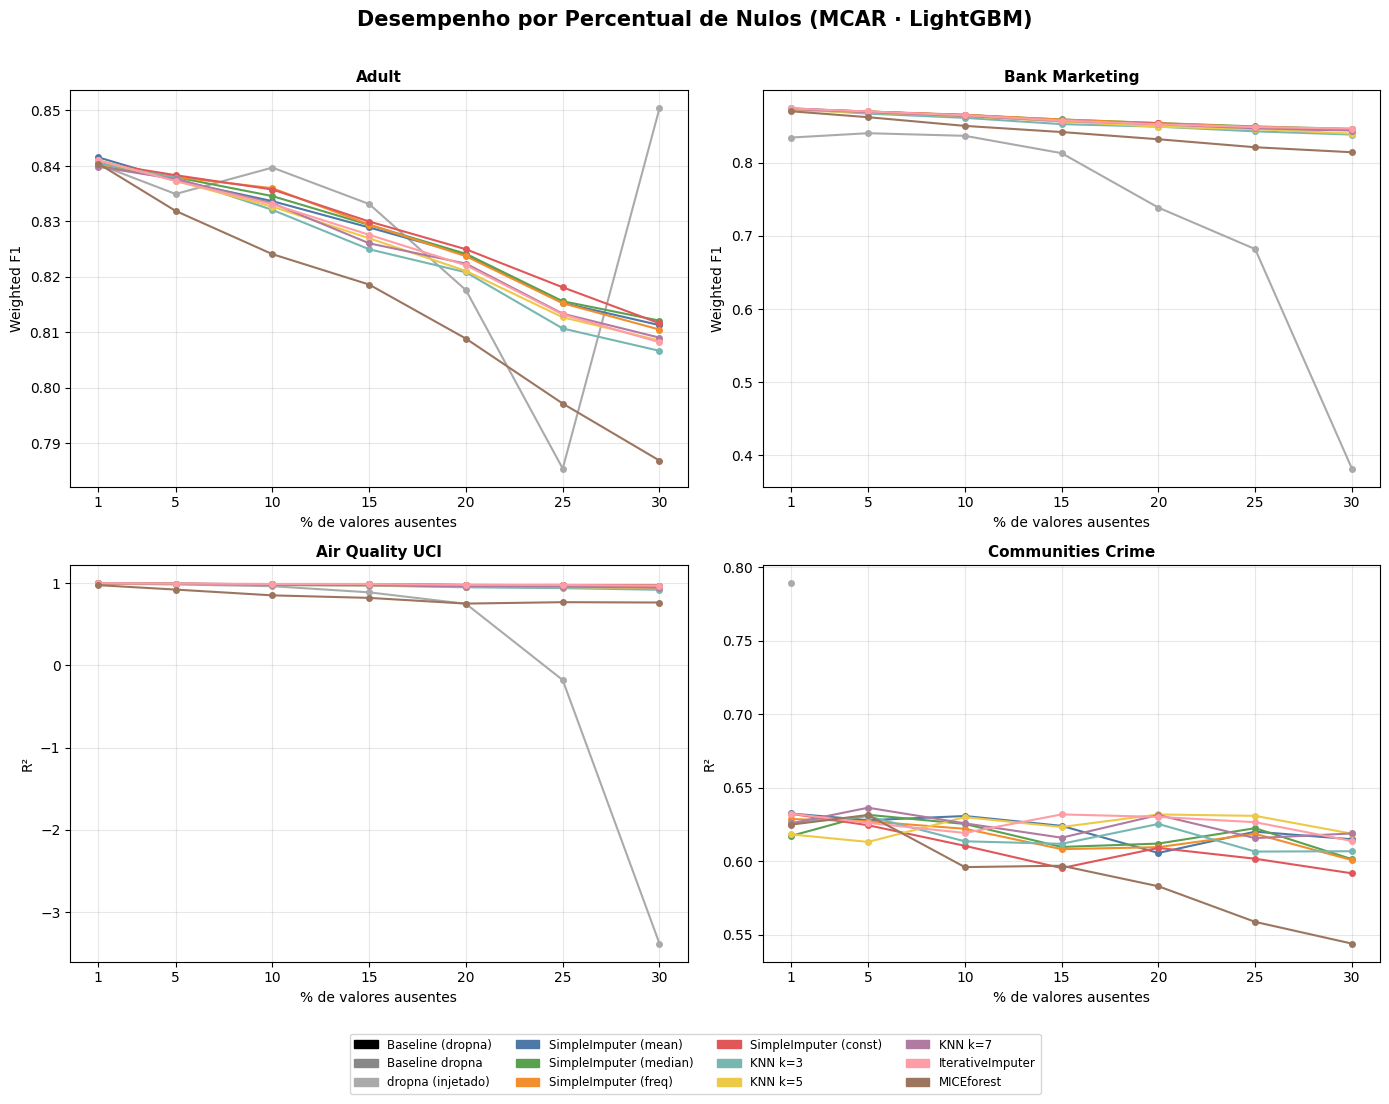

Fig 1 salva.


In [46]:
# Fig 1 — Curvas de desempenho por percentual de nulos (MCAR · LightGBM)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Desempenho por Percentual de Nulos (MCAR · LightGBM)',
             fontsize=15, fontweight='bold', y=1.01)

for ax, ds in zip(axes.flat, DATASETS):
    sub = perf_rate[perf_rate['dataset'] == ds]
    task = sub['task'].iloc[0]
    metric, metric_label = get_metric(task)

    bl = baseline[(baseline['dataset'] == ds) & (baseline['model'] == 'lightgbm')]
    if not bl.empty:
        ax.axhline(bl[metric].values[0], color='black', linestyle='--',
                   linewidth=1.2, label='Baseline (dropna)', zorder=1)

    for imp in IMPUTER_LABELS:
        s = sub[sub['imputer'] == imp].sort_values('rate')
        if s.empty:
            continue
        ax.plot(s['rate'] * 100, s[metric],
                marker='o', markersize=4, linewidth=1.5,
                color=PALETTE.get(imp, 'gray'), label=IMPUTER_LABELS[imp])

    ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='bold')
    ax.set_xlabel('% de valores ausentes')
    ax.set_ylabel(metric_label)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.grid(True, alpha=0.3)

handles = [mpatches.Patch(color='black', label='Baseline (dropna)')]
for imp, label in IMPUTER_LABELS.items():
    handles.append(mpatches.Patch(color=PALETTE.get(imp, 'gray'), label=label))
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=8.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_curvas_percentual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 salva.")


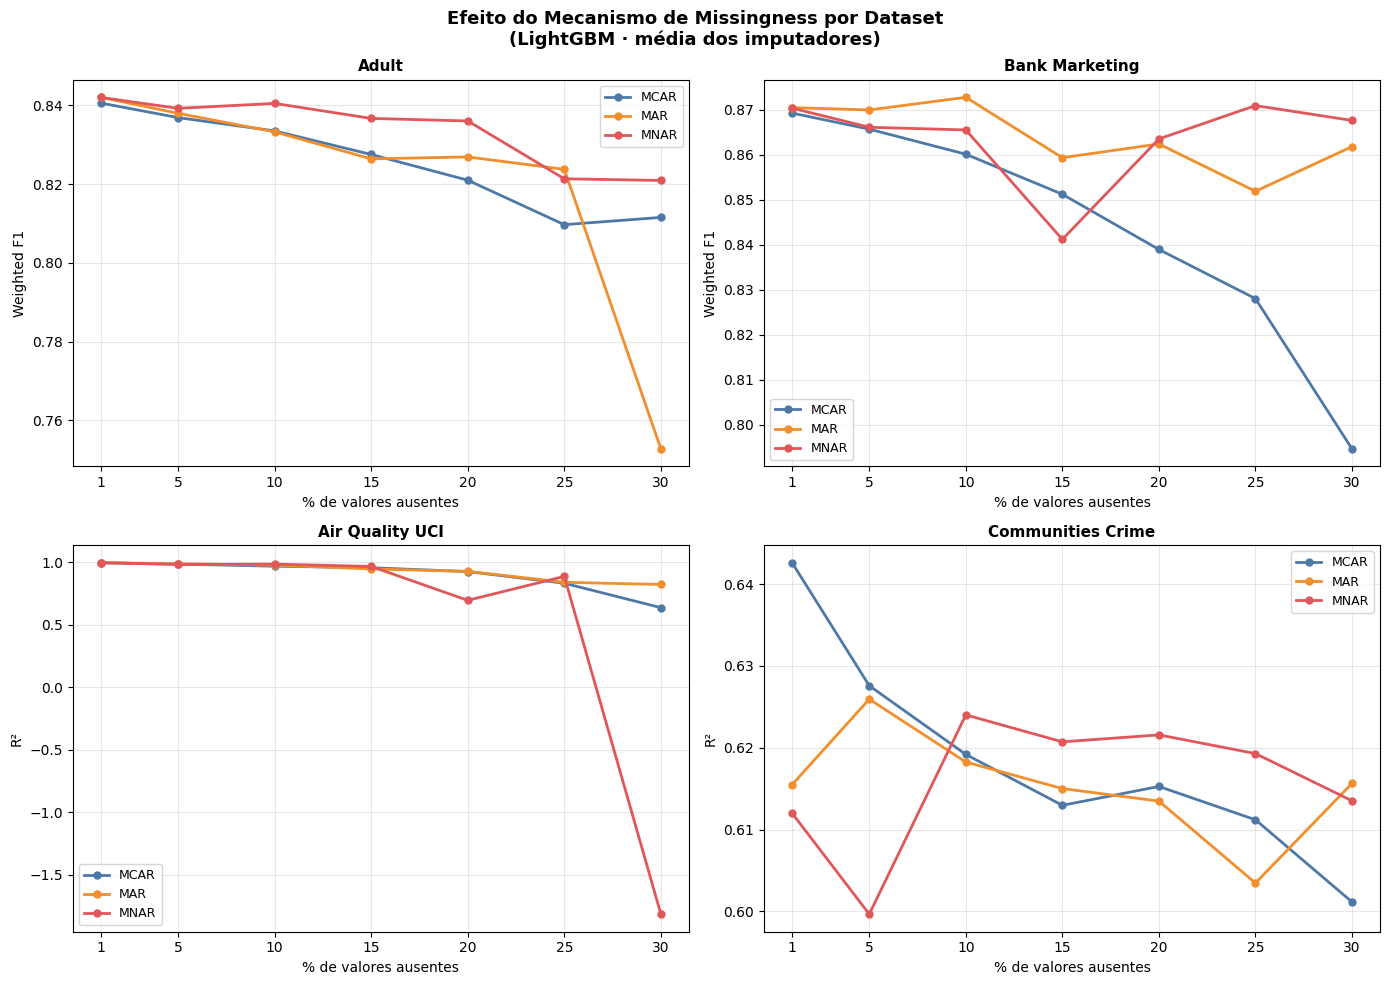

Fig 2 salva.


In [47]:
# Fig 2 — Comparativo MCAR vs MAR vs MNAR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Efeito do Mecanismo de Missingness por Dataset\n(LightGBM · média dos imputadores)',
             fontsize=13, fontweight='bold')

for ax, ds in zip(axes.flat, DATASETS):
    sub = mech_avg[mech_avg['dataset'] == ds]
    task = sub['task'].iloc[0]
    metric, metric_label = get_metric(task)

    bl = baseline[(baseline['dataset'] == ds) & (baseline['model'] == 'lightgbm')]
    if not bl.empty:
        ax.axhline(bl[metric].values[0], color='black', linestyle='--',
                   linewidth=1.2, label='Baseline')

    for mech, color in MECH_COLORS.items():
        s = sub[sub['mechanism'] == mech].sort_values('rate')
        ax.plot(s['rate'] * 100, s[metric], marker='o', markersize=5,
                linewidth=2, color=color, label=mech)

    ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='bold')
    ax.set_xlabel('% de valores ausentes')
    ax.set_ylabel(metric_label)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_mcar_mar_mnar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 salva.")


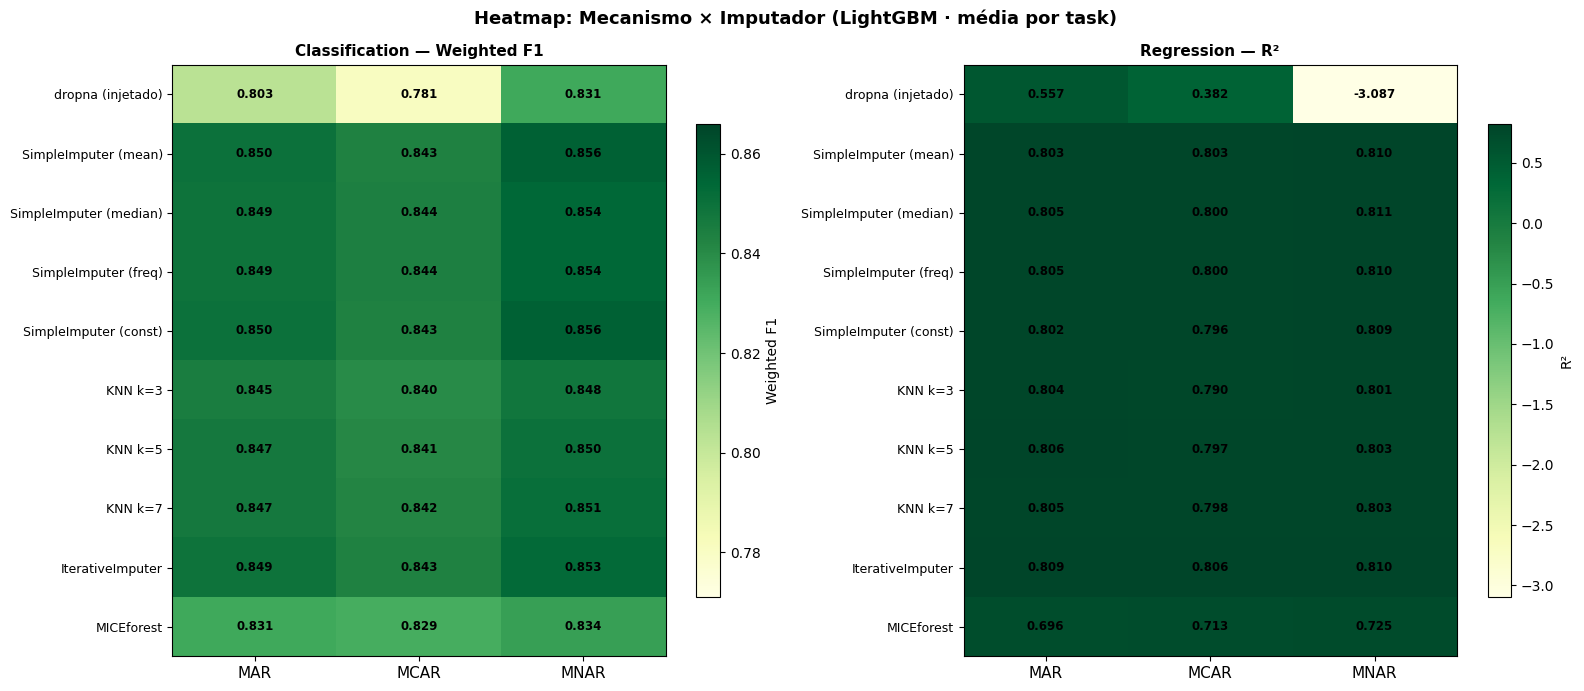

Fig 3 salva.


In [48]:
# Fig 3 — Heatmap mecanismo × imputador
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Heatmap: Mecanismo × Imputador (LightGBM · média por task)',
             fontsize=13, fontweight='bold')

for ax, (task, metric, metric_label) in zip(axes, [
    ('classification', 'weighted_f1', 'Weighted F1'),
    ('regression',     'r2',          'R²'),
]):
    sub = heatmap_df[heatmap_df['task'] == task]
    pivot = sub.pivot(index='imputer', columns='mechanism', values=metric).round(3)
    pivot = pivot.reindex(index=[k for k in IMPUTER_LABELS if k in pivot.index])
    pivot.index = [IMPUTER_LABELS.get(i, i) for i in pivot.index]

    im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn',
                   vmin=pivot.values.min() - 0.01, vmax=pivot.values.max() + 0.01)
    plt.colorbar(im, ax=ax, shrink=0.8, label=metric_label)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(f'{task.capitalize()} — {metric_label}', fontsize=11, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=8.5, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 salva.")


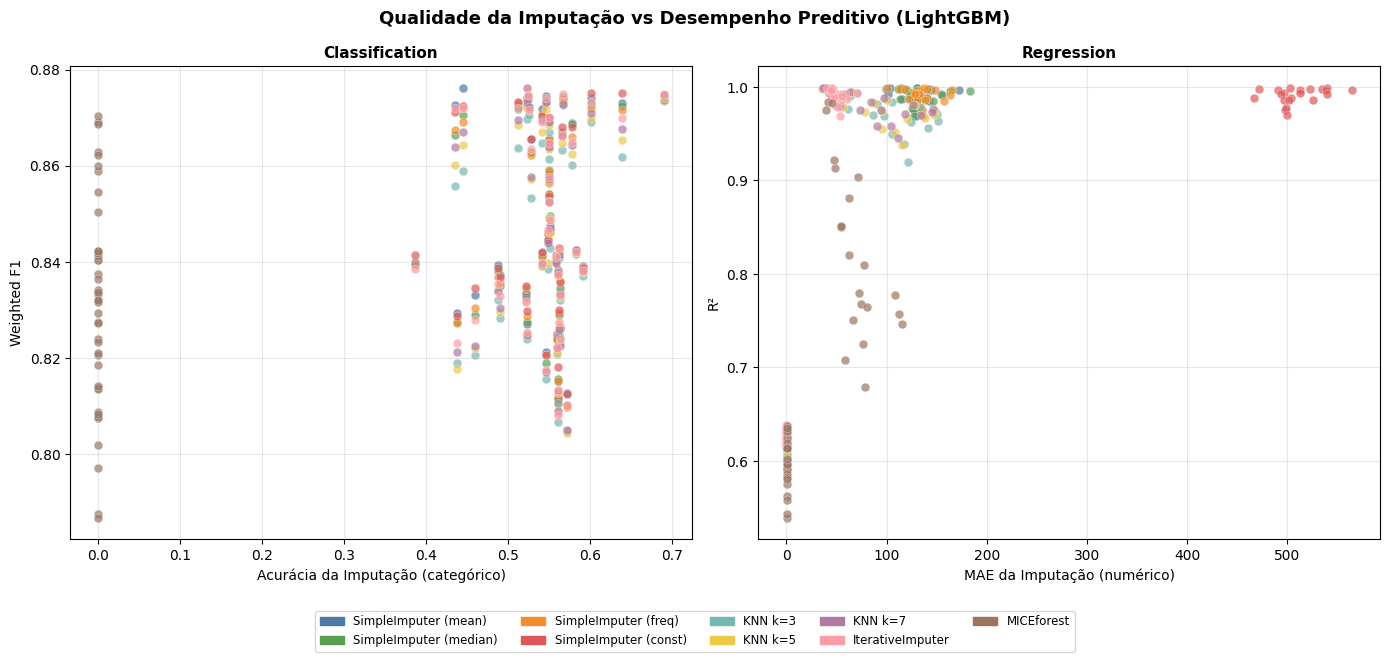

Fig 4 salva.


In [49]:
# Fig 4 — Qualidade da imputação vs desempenho preditivo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Qualidade da Imputação vs Desempenho Preditivo (LightGBM)',
             fontsize=13, fontweight='bold')

imp_vs = imp_vs_pred[imp_vs_pred['imputer'] != 'dropna']

for ax, (task, pred_metric, imp_metric, xlabel, ylabel) in zip(axes, [
    ('classification', 'weighted_f1', 'imp_acc_cat',
     'Acurácia da Imputação (categórico)', 'Weighted F1'),
    ('regression',     'r2',          'imp_mae_num',
     'MAE da Imputação (numérico)',    'R²'),
]):
    sub = imp_vs[imp_vs['task'] == task].dropna(subset=[imp_metric, pred_metric])
    for imp in IMPUTER_LABELS:
        s = sub[sub['imputer'] == imp]
        if s.empty:
            continue
        ax.scatter(s[imp_metric], s[pred_metric],
                   color=PALETTE.get(imp, 'gray'), label=IMPUTER_LABELS[imp],
                   alpha=0.7, s=40, edgecolors='white', linewidths=0.3)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(task.capitalize(), fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

handles2 = [
    mpatches.Patch(color=PALETTE.get(imp, 'gray'), label=IMPUTER_LABELS[imp])
    for imp in IMPUTER_LABELS if imp not in ('baseline_dropna', 'dropna')
]
fig.legend(handles=handles2, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.1), fontsize=8.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_imp_quality_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 salva.")


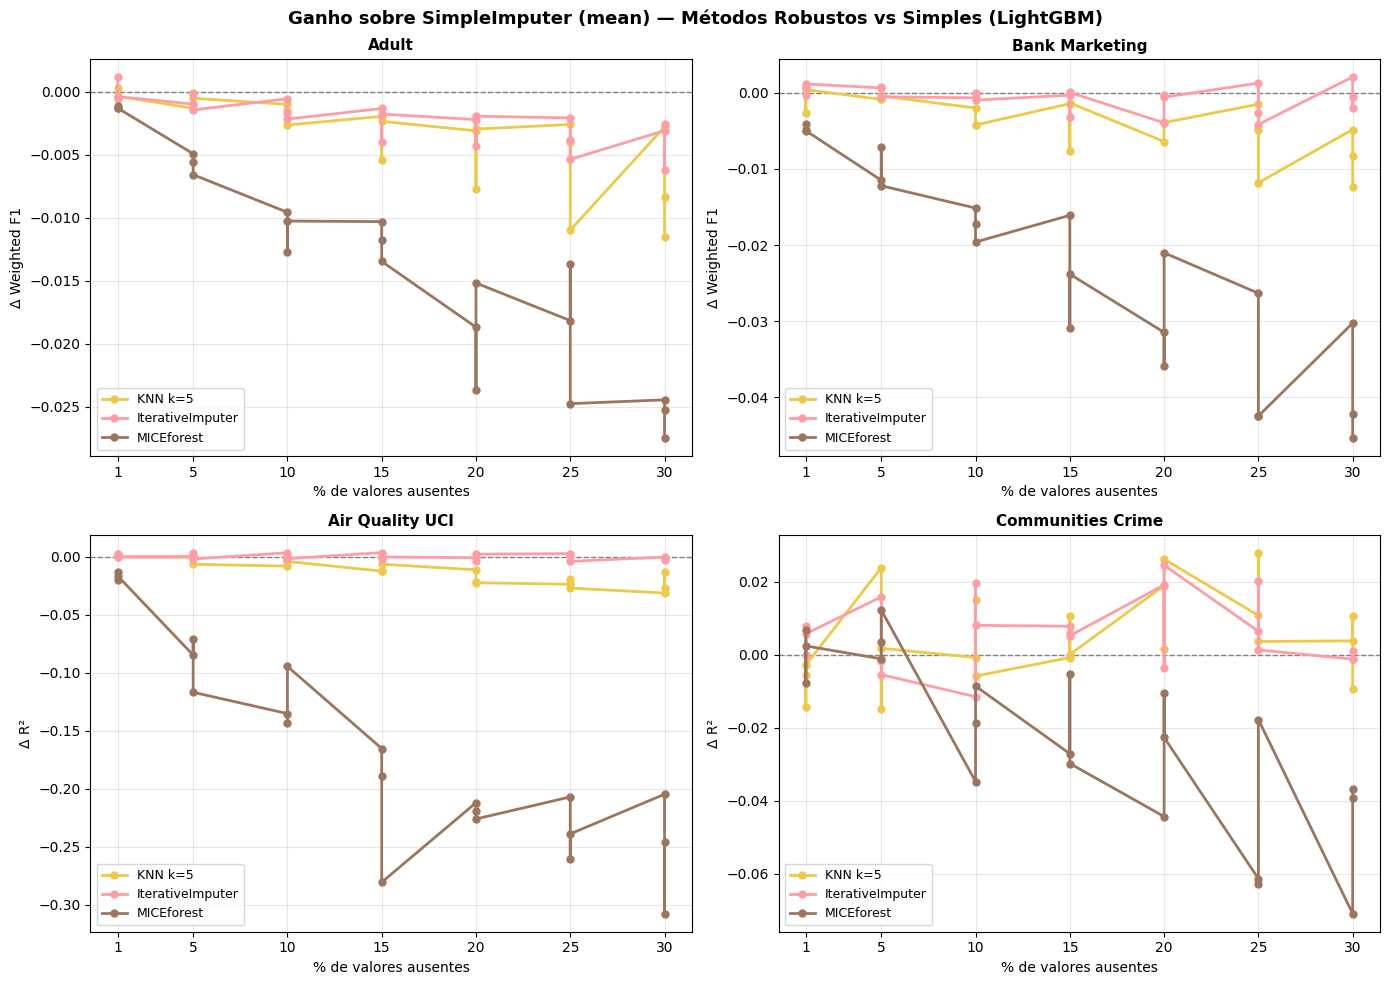

Fig 5 salva.


In [50]:
# Fig 5 — Quando métodos robustos superam SimpleImputer (mean)
robust_imps   = ['knn_5', 'iterative', 'miceforest']
robust_colors = {imp: PALETTE[imp] for imp in robust_imps}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ganho sobre SimpleImputer (mean) — Métodos Robustos vs Simples (LightGBM)',
             fontsize=13, fontweight='bold')

for ax, ds in zip(axes.flat, DATASETS):
    sub = avg_imp[avg_imp['dataset'] == ds]
    task = sub['task'].iloc[0]
    metric, _ = get_metric(task)
    delta_label = 'Δ Weighted F1' if task == 'classification' else 'Δ R²'

    base_imp = sub[sub['imputer'] == 'simple_mean'].set_index('rate')[metric]
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')

    for imp in robust_imps:
        s = sub[sub['imputer'] == imp].set_index('rate')[metric]
        diff = (s - base_imp).dropna().sort_index()
        if diff.empty:
            continue
        ax.plot(diff.index * 100, diff.values, marker='o', markersize=5,
                linewidth=2, color=robust_colors[imp], label=IMPUTER_LABELS[imp])

    ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='bold')
    ax.set_xlabel('% de valores ausentes')
    ax.set_ylabel(delta_label)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_robustos_vs_simples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 salva.")


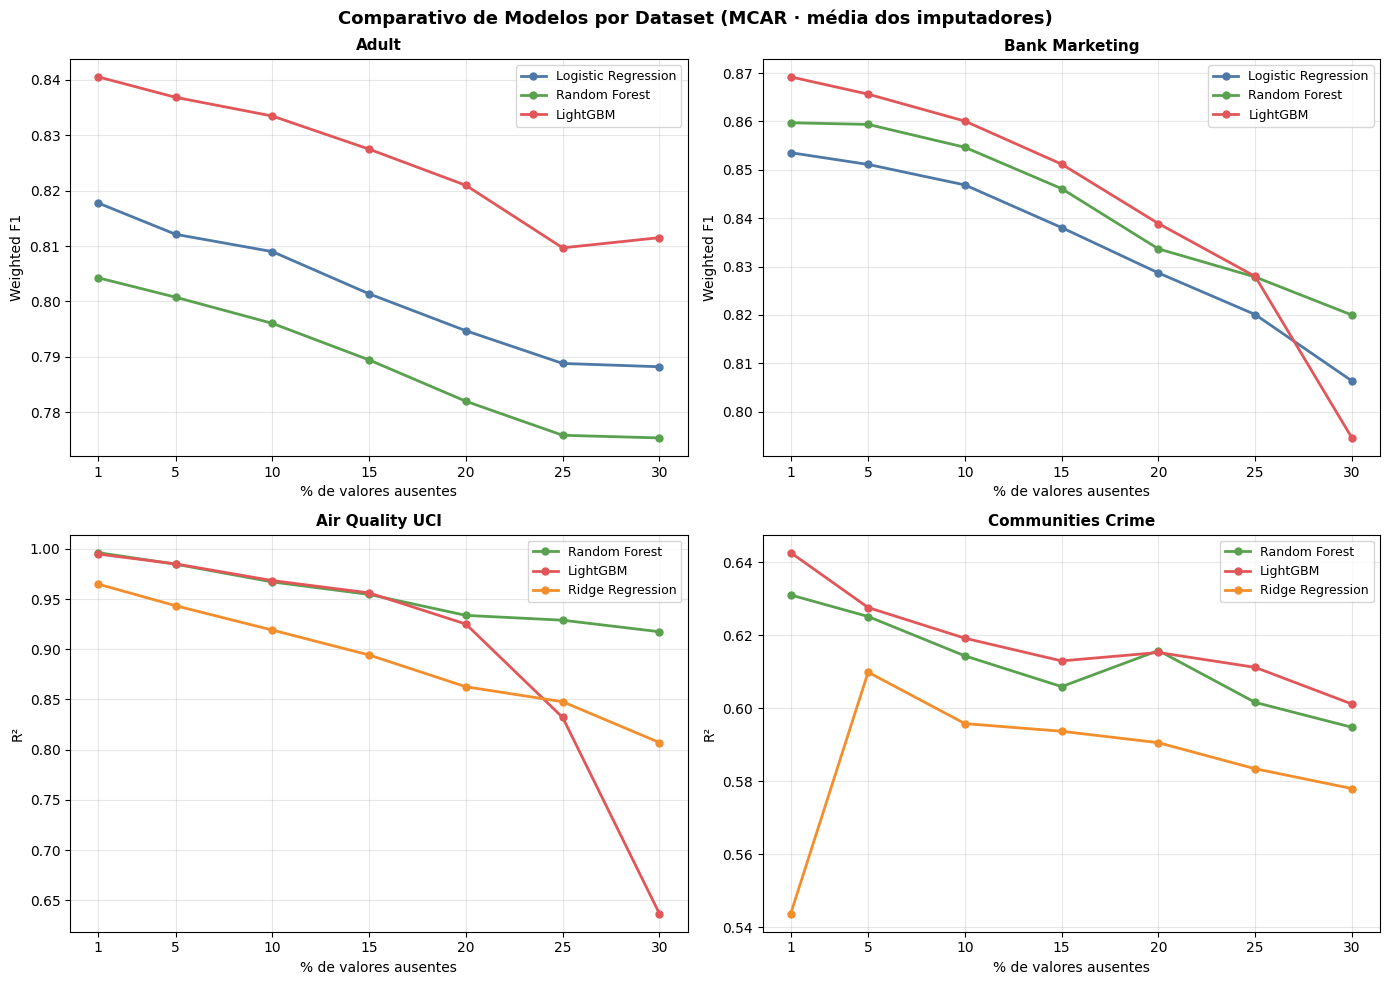

Fig 6 salva.

Todas as figuras salvas em 'figures/'


In [51]:
# Fig 6 — Comparativo de modelos (MCAR · média dos imputadores)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativo de Modelos por Dataset (MCAR · média dos imputadores)',
             fontsize=13, fontweight='bold')

for ax, ds in zip(axes.flat, DATASETS):
    sub = models_mcar[models_mcar['dataset'] == ds]
    task = sub['task'].iloc[0]
    metric, metric_label = get_metric(task)

    for model, color in MODEL_COLORS.items():
        s = sub[sub['model'] == model].sort_values('rate')
        if s.empty:
            continue
        ax.plot(s['rate'] * 100, s[metric], marker='o', markersize=5,
                linewidth=2, color=color, label=MODEL_LABELS[model])

    ax.set_title(DATASET_LABELS[ds], fontsize=11, fontweight='bold')
    ax.set_xlabel('% de valores ausentes')
    ax.set_ylabel(metric_label)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 6 salva.")
print(f"\nTodas as figuras salvas em '{FIGURES_DIR}/'")
